In [1]:
pip install torch torchvision matplotlib scikit-learn pillow seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
DATASET_PATH = "Dataset_BUSI_with_GT"   # If the folder is in the same place as your notebook
# OR use the full path, e.g.:
# DATASET_PATH = r"C:\Users\YourName\Downloads\Dataset_BUSI_with_GT"

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [6]:
# Your dataset path (set above)
DATASET_PATH = "Dataset_BUSI_with_GT"   # <-- UPDATE THIS if needed

base_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

full_dataset = ImageFolder(root=DATASET_PATH, transform=base_transform)
print("Class mapping:", full_dataset.class_to_idx)

# Keep only benign (0) and malignant (1)
targets = full_dataset.targets
class_names = full_dataset.classes
benign_idx = class_names.index('benign')
malignant_idx = class_names.index('malignant')
filtered_indices = [i for i, t in enumerate(targets) if t in [benign_idx, malignant_idx]]
new_targets = [0 if targets[i] == benign_idx else 1 for i in filtered_indices]

Class mapping: {'benign': 0, 'malignant': 1, 'normal': 2}


In [7]:
train_idx, temp_idx = train_test_split(
    filtered_indices, test_size=0.30, random_state=42, stratify=new_targets)

temp_targets = [new_targets[filtered_indices.index(i)] for i in temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, random_state=42, stratify=temp_targets)

print(f"Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}")

Train: 918, Val: 197, Test: 197


In [8]:
train_subset_temp = Subset(full_dataset, train_idx)
means = torch.zeros(3)
stds = torch.zeros(3)
for img, _ in train_subset_temp:
    means += img.mean(dim=(1,2))
    stds  += img.std(dim=(1,2))
means /= len(train_subset_temp)
stds  /= len(train_subset_temp)
print(f"Mean: {means.tolist()}, Std: {stds.tolist()}")

Mean: [0.20958295464515686, 0.20957790315151215, 0.20955465734004974], Std: [0.21867433190345764, 0.21867242455482483, 0.2186615914106369]


In [9]:
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=means, std=stds)
])

val_test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=means, std=stds)
])

In [10]:
full_ds_train = ImageFolder(root=DATASET_PATH, transform=train_transform)
full_ds_val   = ImageFolder(root=DATASET_PATH, transform=val_test_transform)
full_ds_test  = ImageFolder(root=DATASET_PATH, transform=val_test_transform)

train_dataset = Subset(full_ds_train, train_idx)
val_dataset   = Subset(full_ds_val, val_idx)
test_dataset  = Subset(full_ds_test, test_idx)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
print("Data pipelines ready.")

Data pipelines ready.


In [11]:
class CancerCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Block 1
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)
        
        # Block 2
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)
        
        # Block 3
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2, 2)
        
        self.dropout = nn.Dropout(0.4)
        
        # Classifier
        self.flatten = nn.Flatten()
        self.fc1     = nn.Linear(128 * 16 * 16, 256)
        self.relu_fc = nn.ReLU()
        self.fc2     = nn.Linear(256, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu3(self.bn3(self.conv3(x))))
        x = self.dropout(x)
        x = self.flatten(x)
        x = self.relu_fc(self.fc1(x))
        x = self.dropout(x)
        x = self.sigmoid(self.fc2(x))
        return x

model = CancerCNN().to(device)
print(model)

CancerCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.4, inplace=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=32768, out_features=256, bia

In [12]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [13]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device).float().unsqueeze(1)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        predicted = (outputs > 0.5).float()
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    return running_loss / len(loader.dataset), correct / total

def eval_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_probs, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device).float().unsqueeze(1)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            predicted = (outputs > 0.5).float()
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            all_probs.extend(outputs.cpu().numpy().flatten())
            all_labels.extend(labels.cpu().numpy().flatten())
    return running_loss / len(loader.dataset), correct / total, all_probs, all_labels

In [14]:
EPOCHS = 20
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(1, EPOCHS+1):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, _, _ = eval_epoch(model, val_loader, criterion, device)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    print(f"Epoch {epoch:2d}: Train Loss={train_loss:.4f}, Acc={train_acc:.4f} | Val Loss={val_loss:.4f}, Acc={val_acc:.4f}")

Epoch  1: Train Loss=4.9879, Acc=0.5871 | Val Loss=1.3682, Acc=0.5076
Epoch  2: Train Loss=0.7868, Acc=0.6383 | Val Loss=0.6593, Acc=0.6599
Epoch  3: Train Loss=0.6217, Acc=0.6808 | Val Loss=0.6368, Acc=0.6802
Epoch  4: Train Loss=0.6036, Acc=0.7081 | Val Loss=0.6343, Acc=0.6853
Epoch  5: Train Loss=0.5745, Acc=0.7298 | Val Loss=0.5822, Acc=0.6954
Epoch  6: Train Loss=0.5712, Acc=0.7179 | Val Loss=0.5834, Acc=0.6853
Epoch  7: Train Loss=0.5418, Acc=0.7375 | Val Loss=0.5745, Acc=0.6802
Epoch  8: Train Loss=0.5347, Acc=0.7288 | Val Loss=0.5867, Acc=0.6954
Epoch  9: Train Loss=0.5389, Acc=0.7342 | Val Loss=0.5928, Acc=0.7005
Epoch 10: Train Loss=0.5189, Acc=0.7516 | Val Loss=0.5395, Acc=0.7208
Epoch 11: Train Loss=0.5308, Acc=0.7320 | Val Loss=0.5369, Acc=0.7107
Epoch 12: Train Loss=0.5306, Acc=0.7331 | Val Loss=0.6225, Acc=0.7310
Epoch 13: Train Loss=0.5195, Acc=0.7549 | Val Loss=0.5915, Acc=0.7411
Epoch 14: Train Loss=0.4956, Acc=0.7527 | Val Loss=0.5339, Acc=0.7766
Epoch 15: Train Loss

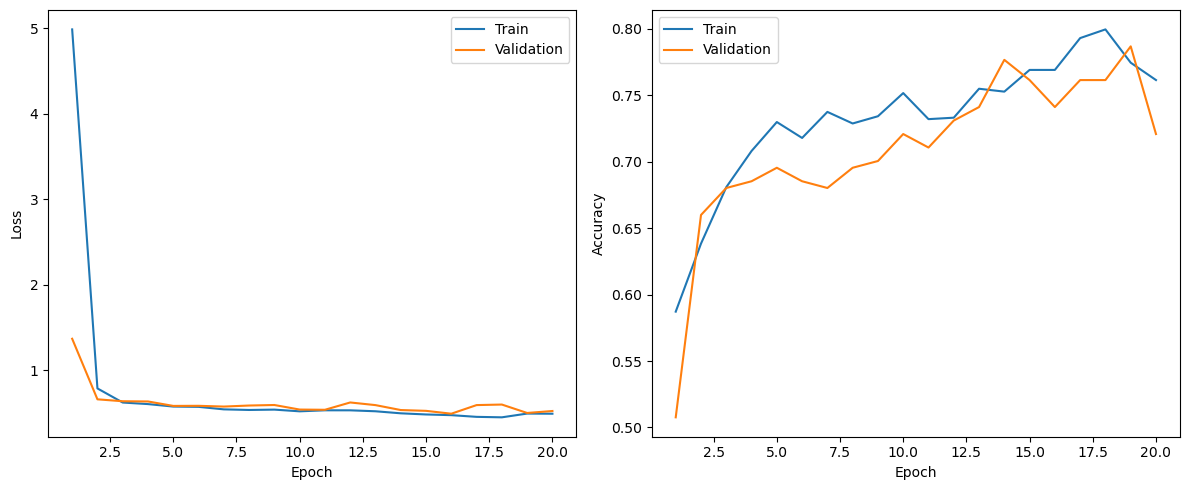

In [24]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(range(1,EPOCHS+1), train_losses, label='Train')
plt.plot(range(1,EPOCHS+1), val_losses, label='Validation')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.subplot(1,2,2)
plt.plot(range(1,EPOCHS+1), train_accs, label='Train')
plt.plot(range(1,EPOCHS+1), val_accs, label='Validation')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150)
plt.show()


Test Accuracy: 0.7665


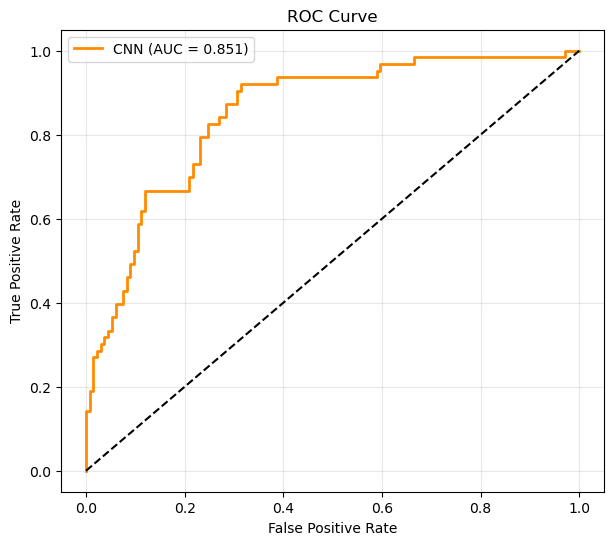

In [25]:
test_loss, test_acc, test_probs, test_labels = eval_epoch(model, test_loader, criterion, device)
print(f"\nTest Accuracy: {test_acc:.4f}")

fpr, tpr, _ = roc_curve(test_labels, test_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'CNN (AUC = {roc_auc:.3f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig('roc_curve.png', dpi=150)
plt.show()

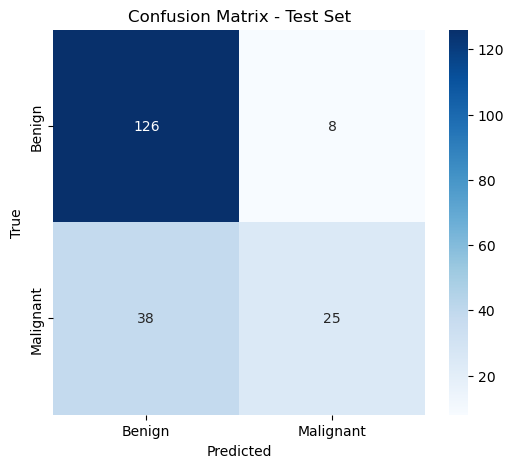

              precision    recall  f1-score   support

      Benign       0.77      0.94      0.85       134
   Malignant       0.76      0.40      0.52        63

    accuracy                           0.77       197
   macro avg       0.76      0.67      0.68       197
weighted avg       0.76      0.77      0.74       197



In [26]:
test_preds = (np.array(test_probs) > 0.5).astype(int)
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign','Malignant'], yticklabels=['Benign','Malignant'])
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print(classification_report(test_labels, test_preds, target_names=['Benign','Malignant']))